# MILESTONE II - VAERS insights: Applying supervised and unsupervised modeling to fatality prediction
### (by Leon Gutierrez, Tung Nguyen, and James Isioma)

### Introduction
Prior to COVID-19, long term studies of vaccine reactions and fatalities were standard. Yet COVID-19 vaccines 
were approved under “Emergency Use Authorization” with limited exploration of possible fatal effects. Despite the 
Freedom of Information Act, pharmaceutical studies remain incomplete. This effort will analyze public data from 
VAERS and health data from CDC sites using supervised and unsupervised algorithms. We hope to find predictive 
factors and hidden trends tied to vaccine related fatalities, addressing incomplete records, sample imbalances, and 
biases. Challenges: However, VAERS depends on self-reported accounts (patients, hospitals, doctors, etc), causing 
differences in data quality. Because of this, many incidents are not reported. Related Work: “Profiling COVID-19 
Vaccine Adverse Events” mapped VAERS data to identify adverse reactions in different COVID-19 vaccines. We 
build on that study by analyzing 2021-2022 data, using supervised and unsupervised models, and centering on 
fatalities. Our approach will addresses incomplete records, sample imbalances, and biases that can affect critical risk 
factor discovery. To address potential underreporting or overrepresentation in the VAERS data, we will explore 
weighting methods that account for demographic and reporting discrepancies.  


In [32]:
import pandas as pd
import numpy as np
import os
import re

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# ML algorithms 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# otherML additional libraries 
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
import shap

# special library for WOE
from optbinning import OptimalBinning

# for replicability
RANDOM_STATE = 501

pd.set_option('display.max_columns', None) 
directory = 'assets/VAERS/'

### Importing  VAERS datasets (demographics, symptoms, and vaccine) - 2021 and 2022  

The Vaccine Adverse Event Reporting System (VAERS) is a national early warning system in the United States that is co-managed by the CDC and FDA. It  collects adverse events following vaccination. It serves as a critical tool for monitoring vaccine safety by gathering information from healthcare providers, manufacturers, and the general public. 

In [49]:

def load_files(directory, file_type):
    vaers = pd.DataFrame()
    for file in os.listdir(directory):
        if file.endswith(file_type + '.csv'): 
            year = file.split('VAERS')[0]  #getting year
            file_path = os.path.join(directory, file)  
            temp_df = pd.read_csv(file_path, encoding='ISO-8859-1', low_memory=False)  # ISO-8859-1 used bc standatd UTF-8 had errors (fields w/free text)
            temp_df['YEAR'] = year 
            vaers = pd.concat([vaers, temp_df], ignore_index=True)  
    return vaers

vaersdata = load_files(directory, 'VAERSDATA')
#vaerssymptoms = load_files(directory, 'VAERSSYMPTOMS')   Not longer needed as this one was only used in the unsupervised section
vaersvax = load_files(directory, 'VAERSVAX')

print('\nTotal rows for all dfs and all years + proposed Target\n')
combined = pd.concat([vaersdata['YEAR'].value_counts().sort_index(),vaersvax['YEAR'].value_counts().sort_index(),vaersdata.groupby('YEAR')[['DIED']].apply(lambda x: x.notnull().sum())], axis=1)
combined.columns = ['vaersdata', 'vaersvax','Target - Died']
combined


Total rows for all dfs and all years + proposed Target



,vaersdata,vaersvax,Target - Died
YEAR,,,
2019,48438,61194,182
2020,49688,59699,171
2021,753032,797101,10530
2022,246806,283415,6490
2023,106083,128248,2097


## Special Filters

In [3]:
################## TUNG TUNG TUNG ADD Version1 filter here and any other needed if any. USE combined df. 

### All Cause Mortality datasets - CDC WONDER database - VAERS enhancement 1
CDC WONDER is an online database maintained by the CDC that provides access to various public health datasets. One key dataset, the All-Cause Mortality dataset, compiles death certificate information from across the U.S., allowing users to analyze mortality statistics by factors such as gender, age, race, ethnicity, state, county, and underlying causes of death.


In [50]:
files = ['assets/CDC_AllCauseMortality/2021.txt', 'assets/CDC_AllCauseMortality/2022.txt']
df_ACM = pd.DataFrame()

for file_path in files:
    data = pd.read_csv(file_path, delimiter='\t')
    data = data.dropna(subset=['State'], how='all')

    # note:gender NaN means total for the state
    data['Gender'] = data['Gender'].fillna('Total') 
    data = data[['State', 'Gender', 'Crude Rate']].copy()

    # extract year from file names
    data['Year'] = file_path.split('/')[-1].split('.')[0]

    #long to wide format
    pivot_data = data.pivot_table(index=['State', 'Year'], columns='Gender', values='Crude Rate', aggfunc='first').reset_index()
    df_ACM = pd.concat([df_ACM, pivot_data], ignore_index=True)

# Creating rates that are comparable between states (every 1000 instead of 100,000 for readability purposes)
df_ACM['ACM_F'] = df_ACM.get('Female', 0) / 100
df_ACM['ACM_M'] =df_ACM.get('Male', 0) / 100
df_ACM['ACM_T'] = df_ACM.get('Total', 0) / 100
df_ACM.drop(columns=['Female', 'Male', 'Total'], inplace=True)
df_ACM.columns = df_ACM.columns.str.upper()

### Diabetes Datasets - VAERS enhancement 2
CDC WONDER is an online database maintained by the CDC that provides access to a variety of public health datasets. One key dataset, the All-Cause Mortality dataset, compiles death records from across the United States. Evidence suggests that comorbidities like diabetes may elevate the risk of fatal outcomes. Since the data is depersonalized, we are analyzing state-level information to explore these associations. This approach aims to uncover any potential links between these comorbidities and mortality.

In [51]:
files = ['assets/CDC_Diabetes/DiabetesAtlasData_2021.csv','assets/CDC_Diabetes/DiabetesAtlasData_2022.csv']
dataframes = []

for year, file in zip([2021, 2022], files):
    df = pd.read_csv(file, skiprows=3)                     # first 3 rows not needed
    df.columns = ['STATE', 'DIABETES_RATE', 'LL', 'UL']
    df = df.dropna(subset=['DIABETES_RATE'], how='all')
    df['YEAR'] = year
    dataframes.append(df)

merged_diabetes = pd.concat(dataframes)
merged_diabetes = merged_diabetes[~merged_diabetes['STATE'].str.contains("US Diabetes Surveillance System", na=False)]

df_diabetes = merged_diabetes[['STATE', 'DIABETES_RATE', 'YEAR']].copy()
# needed to change type due to errors in the merge (mixing types). Then strip spaces to fix merge issues
df_diabetes['YEAR'] = df_diabetes['YEAR'].astype(str).str.strip()
df_diabetes['STATE'] = df_diabetes['STATE'].str.strip()

#df_diabetes.sample(4)

### Standardize State for dataframes joining purposes  

There was a need to create a data dictionary so that we could standardize the variable 'STATE' across all datasets. All-cause-mortality and diabetes datasets are at the state level. So that will serve as a key for joining secondary dataframes to VAERS data.

In [52]:
# dictionary to map values from original df's
state_map = {
    'IL': 'Illinois', 'MA': 'Massachusetts', 'UT': 'Utah', 'TX': 'Texas', 'MN': 'Minnesota', 'GA': 'Georgia',
    'MD': 'Maryland', 'AZ': 'Arizona', 'CT': 'Connecticut', 'KS': 'Kansas', 'CA': 'California', 'NC': 'North Carolina',
    'VA': 'Virginia', 'MS': 'Mississippi', 'NJ': 'New Jersey', 'PA': 'Pennsylvania', 'LA': 'Louisiana', 'MI': 'Michigan',
    'IN': 'Indiana', 'NM': 'New Mexico', 'NY': 'New York', 'FL': 'Florida', 'WA': 'Washington', 'WV': 'West Virginia',
    'OH': 'Ohio', 'AK': 'Alaska', 'KY': 'Kentucky', 'ME': 'Maine', 'OR': 'Oregon', 'IA': 'Iowa', 'OK': 'Oklahoma',
    'AR': 'Arkansas', 'CO': 'Colorado', 'MO': 'Missouri', 'MT': 'Montana', 'AL': 'Alabama', 'SC': 'South Carolina',
    'ND': 'North Dakota', 'NV': 'Nevada', 'TN': 'Tennessee', 'WI': 'Wisconsin', 'SD': 'South Dakota', 'PR': 'Puerto Rico',
    'ID': 'Idaho', 'ME': 'Maine', 'VI': 'Virgin Islands of the U.S.', 'VT': 'Vermont', 'NH': 'New Hampshire',
    'DC': 'District of Columbia', 'NE': 'Nebraska', 'HI': 'Hawaii', 'DE': 'Delaware', 'RI': 'Rhode Island', 
    'FM': 'Micronesia', 'GU': 'Guam', 'MP': 'Northern Mariana Islands', 'PW': 'Palau', 'AS': 'American Samoa'}

# note:vaersdata contains some lowercase state codes...
vaersdata['STATE'] = vaersdata['STATE'].str.upper().map(state_map)
df_ACM['STATE'] = df_ACM['STATE'].map(lambda x: state_map.get(x, x))
df_diabetes['STATE'] = df_diabetes['STATE'].map(lambda x: state_map.get(x, x))


### Merging Vaers data and VAERS vax to create vaers_covid

In [53]:
vaersvax_covid = vaersvax[vaersvax['VAX_NAME'].str.contains('COVID', case=False, na=False)]  #filtering only COVID vaccine rows 
df_VAERS_covid = pd.merge(vaersdata,vaersvax_covid,  on='VAERS_ID', how='inner')
df_VAERS_covid = df_VAERS_covid.drop(columns=['YEAR_y']).rename(columns={'YEAR_x': 'YEAR'})
print(pd.concat([df_VAERS_covid['YEAR'].value_counts().sort_index(), df_VAERS_covid.groupby('YEAR')['DIED'].apply(lambda x: x.notnull().sum())],axis=1, 
                keys=['TotRows', 'Target - DIED']))

      TotRows  Target - DIED
YEAR                        
2020    10397             16
2021   742046          11907
2022   232200           7921
2023    77462           2280


### Merging df_VAERS_covid with Diabetes and All Cause Mortality dataframes

In [39]:
df_VAERS_covid_M = df_VAERS_covid.merge(df_ACM, on=['STATE', 'YEAR'], how='left')
df_VAERS_covid_M_D = df_VAERS_covid_M.merge(df_diabetes, on=['STATE', 'YEAR'], how='left')

df_VAERS_covid_M_D.sample(2)

,VAERS_ID,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,DATEDIED,L_THREAT,ER_VISIT,HOSPITAL,HOSPDAYS,X_STAY,DISABLE,RECOVD,VAX_DATE,ONSET_DATE,NUMDAYS,LAB_DATA,V_ADMINBY,V_FUNDBY,OTHER_MEDS,CUR_ILL,HISTORY,PRIOR_VAX,SPLTTYPE,FORM_VERS,TODAYS_DATE,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES,YEAR,VAX_TYPE,VAX_MANU,VAX_LOT,VAX_DOSE_SERIES,VAX_ROUTE,VAX_SITE,VAX_NAME,ACM_F,ACM_M,ACM_T,DIABETES_RATE
45905,965683,01/22/2021,Washington,67.0,67.0,NaN,F,NaN,"lump on side of whole left side of face, face ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,01/20/2021,01/20/2021,0.0,lab and cat scan,PVT,NaN,"symbicort, enalaporil, ezetimibe, hydroxyzine,...",NaN,"asthma, copd, high blood pressure and cholesterol",NaN,NaN,2,01/22/2021,NaN,NaN,Y,phenegran,2021,COVID19,MODERNA,FC0001665736,1,IM,LA,COVID19 (COVID19 (MODERNA)),8.326,9.418,8.876,7.9
190175,1130681,03/24/2021,Virginia,63.0,63.0,NaN,F,NaN,Saturday morning I woke up feeling fine. About...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,03/18/2021,03/20/2021,2.0,none,OTH,NaN,Pravachol 20 mg ?? daily Zyrtec ?- Daily Beni...,none that I am aware of,"MS, heart disease,",NaN,NaN,2,03/24/2021,NaN,NaN,NaN,none,2021,COVID19,PFIZER\BIONTECH,EP7534,1,NaN,RA,COVID19 (COVID19 (PFIZER-BIONTECH)),9.422,10.477,9.944,10.2


### UNSUPERVISED - ADD HERE


In [40]:
## TUNG, at the end of the unsupervised section, I need your dataset to be called df_unsup

### SUPERVISED LEARNING

1. Data Preparation for Supervised Modeling:

   
    a) We standardize numeric features, and split into training and test sets with stratification and class weights  
    b) Missings are controlled through WOE using Optbinning to estimate optimal bins(bins based only on the training data to avoid leakage)  
    c) Some variables made common sense to enforce motononicity. Se we created monotonic_vars to enforce it in those variables  

3. Modeling:

    a) We trained three models: Logistic Regression, Random Forest, and a Boosting model (XGB)  
    b) Models were trained with hyperparameter tuning  
    c)We used same random state to ensure replicability  

5. Performance Evaluation:

   
    a) ROC curves for all models are computed and plotted alongside a random guess (50% chance) diagonal
    b) Confusion matrices and classification reports are displayed

### Feature Engineering  

Most of the new features were created here, but a couple of them come from the unsupervised learning (clustering)


In [41]:
brands = ['PFIZER','MODERNA','UNKNOWN','JANSSEN', 'NOVAVAX']

def allergies_flagger(allergies_v):
    if pd.isna(allergies_v):                                    # Handle NaN values
        return 0
    elif allergies_v.strip().upper() =='PCN':
        return 1
    elif len(allergies_v)<= 4:                                 # this captures all cases of null, the only exception was PCN
        return 0
    else:
        return 1
        
def meds_cnt(meds):                                            # Simple count of the meds (clening for mg)
    if pd.isnull(meds) or meds.strip() == '':
        return 0
    if ',' in meds:
        tokens = meds.split(',')
        cnt = 0
        for token in tokens:
            token = token.strip()
            token= re.sub(r'\b\d+\s*mg\b', '', token, flags=re.IGNORECASE).strip()  
            if token:
                cnt += 1
        return cnt
    else:
        tokens= meds.split()
        cnt= 0
        for token in tokens:
            if re.fullmatch(r'\d+', token) or token.lower() == 'mg':
                continue
            cnt += 1
        return cnt
        
def brand(vax_name):                                         
    if pd.isnull(vax_name):
        return None
    vax_name_upper =vax_name.upper()
    for brand in brands:
        if brand in vax_name_upper:
            return brand
            
def bivalent_flagger(vax_name):
    if pd.isnull(vax_name):
        return 0
    return 1 if 'BIVALENT' in vax_name.upper() else 0
    
def dosis_conv(dosis):
    if pd.isnull(dosis) or dosis == 'UNK':
        return 0
    dosis = str(dosis)
    if '7+' in dosis:
        return 7
    try:
        return int(dosis)
    except ValueError:
        return 0

def acm_calc(df):
    df['ACM_Calc'] = np.where(df['SEX'] == 'M', df['ACM_M'],np.where(df['SEX'] == 'F', df['ACM_F'], df['ACM_T']))    # to merge ACM into a single field based on SEX
    df.drop(['ACM_F', 'ACM_M', 'ACM_T'], axis=1, inplace=True)   # Drop the original columns
    return df

def adverse_events_flagger(df):
    cols = ['BIRTH_DEFECT', 'DISABLE', 'X_STAY', 'ER_VISIT', 'L_THREAT']
    df['ADVERSE_EVENTS'] = np.where(df[cols].sum(axis=1) > 0, 1, 0)
    df.drop(columns=cols, inplace=True)
    return df
    
# features that use the above functions
df_VAERS_covid_M_D['ALLERGIES_B'] = df_VAERS_covid_M_D['ALLERGIES'].apply(allergies_flagger)
df_VAERS_covid_M_D['OTHER_MEDS_CNT'] = df_VAERS_covid_M_D['OTHER_MEDS'].apply(meds_cnt)
df_VAERS_covid_M_D['VAX_BRAND'] = df_VAERS_covid_M_D['VAX_NAME'].apply(brand)
#df_VAERS_covid_M_D['BIVALENT'] = df_VAERS_covid_M_D['VAX_NAME'].apply(bivalent_flagger)  # Negligable volume
df_VAERS_covid_M_D['VAX_DOSE_SERIES'] = df_VAERS_covid_M_D['VAX_DOSE_SERIES'].apply(dosis_conv)
#df_VAERS_covid_M_D['PRIOR_VAX_binary'] = df_VAERS_covid_M_D['PRIOR_VAX'].apply(lambda x: 1 if pd.notnull(x) and x.strip() != "" else 0) # Negligable volume
df_VAERS_covid_M_D = acm_calc(df_VAERS_covid_M_D)

# features that were binary already, just recoding them as 0 or 1 to avoid nan. all of them only had Y and nan prior to recoding
df_VAERS_covid_M_D['DIED'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['DIED']]     #target
df_VAERS_covid_M_D['L_THREAT'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['L_THREAT']]
df_VAERS_covid_M_D['ER_VISIT'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['ER_VISIT']]
df_VAERS_covid_M_D['HOSPITAL'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['HOSPITAL']]
df_VAERS_covid_M_D['X_STAY'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['X_STAY']]
df_VAERS_covid_M_D['DISABLE'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['DISABLE']]
df_VAERS_covid_M_D['BIRTH_DEFECT'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['BIRTH_DEFECT']]
df_VAERS_covid_M_D['OFC_VISIT'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['OFC_VISIT']]
df_VAERS_covid_M_D['ER_ED_VISIT'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['ER_ED_VISIT']]
df_VAERS_covid_M_D['DISABLE'] = [1 if x == 'Y' else 0 for x in df_VAERS_covid_M_D['DISABLE']]
df_VAERS_covid_M_D = adverse_events_flagger(df_VAERS_covid_M_D)

### Dropping variables not to be used in the Supervised Learning

  Reasons why these variables were dropped
  
1. Several variables were transformed in the feature engeneering section (i.e. OTHER_MEDS used as cnt or ALLERGIES transformed to ALLERGIES_B), so original variable was not longer needed
2. They should not be used  (like DATEDIED or YEAR)
3. They are part of the unsupevised process (i.e. symptoms_text or comorbidities)

In [43]:
notX = ['RECVDATE','RPT_DATE', 'SYMPTOM_TEXT', 'VAX_DATE','ONSET_DATE', 'LAB_DATA', 'V_FUNDBY','OTHER_MEDS',
        'PRIOR_VAX','CAGE_YR', 'HOSPDAYS','CAGE_MO','FORM_VERS','TODAYS_DATE', 'ALLERGIES', 'YEAR','VAX_TYPE','VAX_MANU', 
        'VAX_LOT', 'CUR_ILL','HISTORY', 'STATE','VAX_DOSE_SERIES','SPLTTYPE','VAX_NAME', 'DATEDIED','RECOVD']

df_sup = df_VAERS_covid_M_D.drop(notX,axis=1)
df_unsup = pd.read_csv('/users/deriv/MADS/0.696_programming/assets/symptom_cluster_counts.csv', low_memory=False) #### NOT NEEDED LATER W TUNG ADDS
df_supunsup = df_sup.merge(df_unsup, on='VAERS_ID', how='left')                                             #### NOT NEEDED LATER W TUNG ADDS

In [12]:
#DELETE DELETE DELETE
ablation_and_Imp_drop = ['SYMPTOM_CLUSTER_1','SYMPTOM_CLUSTER_2','SYMPTOM_CLUSTER_4', 'SYMPTOM_CLUSTER_5','SYMPTOM_CLUSTER_6','SYMPTOM_CLUSTER_7',
                'SYMPTOM_CLUSTER_9','SYMPTOM_CLUSTER_11','SYMPTOM_CLUSTER_15','SYMPTOM_CLUSTER_17','SYMPTOM_CLUSTER_19','SYMPTOM_CLUSTER_20',
                'SYMPTOM_CLUSTER_21','SYMPTOM_CLUSTER_22','SYMPTOM_CLUSTER_24','SYMPTOM_CLUSTER_25','SYMPTOM_CLUSTER_27','SYMPTOM_CLUSTER_28',
                'SYMPTOM_CLUSTER_29','SYMPTOM_CLUSTER_30','SYMPTOM_CLUSTER_31','SYMPTOM_CLUSTER_33','SYMPTOM_CLUSTER_36','ADVERSE_EVENTS']

df_supunsup.drop(ablation_and_Imp_drop, axis=1, inplace=True)


In [13]:
df_supunsup.columns

Index(['VAERS_ID', 'AGE_YRS', 'SEX', 'DIED', 'HOSPITAL', 'NUMDAYS',
       'V_ADMINBY', 'OFC_VISIT', 'ER_ED_VISIT', 'VAX_ROUTE', 'VAX_SITE',
       'DIABETES_RATE', 'ALLERGIES_B', 'OTHER_MEDS_CNT', 'VAX_BRAND',
       'ACM_Calc', 'TOTAL_SYMPTOMS', 'SYMPTOM_CLUSTER_3', 'SYMPTOM_CLUSTER_8',
       'SYMPTOM_CLUSTER_10', 'SYMPTOM_CLUSTER_12', 'SYMPTOM_CLUSTER_13',
       'SYMPTOM_CLUSTER_14', 'SYMPTOM_CLUSTER_16', 'SYMPTOM_CLUSTER_18',
       'SYMPTOM_CLUSTER_23', 'SYMPTOM_CLUSTER_26', 'SYMPTOM_CLUSTER_32',
       'SYMPTOM_CLUSTER_34', 'SYMPTOM_CLUSTER_35', 'SYMPTOM_CLUSTER_37'],
      dtype='object')

### Variable Standardization

We identify numeric features and standardize them using a StandardScaler

In [14]:
# scaler to be applied to numeric only except target
num_cols = df_supunsup.select_dtypes(include=[np.number]).columns.tolist()
if 'DIED' in num_cols:
    num_cols.remove('DIED')
    
scaler = StandardScaler()
df_supunsup[num_cols] = scaler.fit_transform(df_supunsup[num_cols])

### Sampling and Train-Test Split

We define the matrix X (explanatory vars) and target, perform a stratified smapling (on target) train-test split (70% training, 30% testing), and compute class weights (to help with the imbalanced target, where approx. 2% died). A sample weight vector is created for training.

In [15]:
# X and y split
X = df_supunsup.drop(columns=['DIED'])
y = df_supunsup['DIED']

# stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, "Test shape:", X_test.shape)

# creating class weights diue to imbalanced target. 
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
print('Class weights:', class_weight_dict)

# Create sample_weight vector
sample_weight = y_train.map(class_weight_dict)

Train shape: (743473, 30) Test shape: (318632, 30)
Class weights: {0: 0.5106368803795678, 1: 24.003131658810616}


### Cross-Validation Setup

We set up 5‑fold stratified cross‑validation to evaluate our models.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Optimal Binning for WOE Transformation  

The reason for using WOE is to control for missing values. It allows this category to get their real good/bad relationship to be used in the predictions as oposed to assigned an average or a category that is the most common. Two functions were created to allow for easy calculation of WOE for all variables:  

1. fit_optimal_binning: We loop through each feature in the training df (excl. the target), this step also identify whether features are numerical or categorical, then it enforces a monotonic trend for variables in the list monotonic_vars, fits an OptimalBinning model on the training data, and transforms the feature into WOE values. The OptimalBinning objects are saved in a dictionary  

2. transform_optimal_binning: then we use the OptimalBinning objects fitted on the training data to transform the test set using the same bins, ensuring no leakage. 

In [17]:
def fit_optimal_binning(X_train, y_train, monotonic_vars):
    # fits OptimalBinning objects on the training data for each feature (excluding the target)
    # returns a df with WOE-transformed training features and a dictionary of OptimalBinning objects
    binning_dict = {}
    X_train_woe = pd.DataFrame(index=X_train.index)
    
    for col in X_train.columns:
        try:
            # Feature type
            if pd.api.types.is_numeric_dtype(X_train[col]):
                dtype = 'numerical'
            else:
                dtype = 'categorical'
                X_train[col] = X_train[col].fillna('Missing')
            
            monotonic_trend = 'auto' if col in monotonic_vars else None           # Enforcing monotonicity
            optb = OptimalBinning(name=col, dtype=dtype, monotonic_trend=monotonic_trend)
            optb.fit(X_train[col].values, y_train.values)
            
            # transformati0on to WOE values
            woe_values = optb.transform(X_train[col].values, metric='woe')
            
            # if the transformation yields only one unique value, keep original column   ################################### 
            if len(np.unique(woe_values)) == 1:
                X_train_woe[col] = X_train[col]
            else:
                X_train_woe[col] = woe_values
            binning_dict[col] = optb
            #print(f"{col} binned ok.")
        except Exception as e:
            print(f"binning with error {col}: {e}")
            X_train_woe[col] = X_train[col]
    return X_train_woe, binning_dict
    
def transform_optimal_binning(X_test, binning_dict):
    # applies bins to test df
    # returns a DataFrame with WOE on test                      
    X_test_woe = pd.DataFrame(index=X_test.index)
    
    for col in X_test.columns:
        if col in binning_dict:
            optb = binning_dict[col]
            try:
                woe_values = optb.transform(X_test[col].values, metric='woe')
                X_test_woe[col] = woe_values
                #print(col, 'transformed successfully')
            except Exception as e:
                print(col, 'error')
                X_test_woe[col] = X_test[col]
        else:
            X_test_woe[col] = X_test[col]
    return X_test_woe

monotonic_vars = ['OTHER_MEDS_CNT', 'AGE_YRS', 'NUMDAYS']

# fitting on training df
X_train_woe, binning_dict = fit_optimal_binning(X_train, y_train, monotonic_vars)

# applyying fitted binning to test df
X_test_woe = transform_optimal_binning(X_test, binning_dict)

# replacing features values their WOE
X_train = X_train_woe.copy()
X_test = X_test_woe.copy()

## Supervised Modeling

Using the WOE transformatios, we now train three models:

1. Logistic Regression: A baseline linear model with L2 regularization (to help control for multicolinearity and overfitting)
2. Random Forest: We train this mdoel and XGB with hyperparameter tuning
3. Boosting (XGBoost): A gradient boosting model was also used to ensure we end up with an optimal model

<small>Note: Hyperparameter tuning is performed using RandomizedSearchCV</small>

### Base Model: Logistic Regression
We train a logistic regression model with cross-validation to select the best regularization parameter C (hyperparameter that controls the regularization strength). Results based on ROC AUC

In [18]:
def base_model_lr(X_tr, y_tr, cv, sample_wt):
    #logistic with cross‑validation - returns best model specs and CV ROC AUC scores
    lr = LogisticRegression(class_weight=class_weight_dict, solver='liblinear', random_state=RANDOM_STATE)
    param_grid = {'C': [0.01, 0.1, 1, 10, 20]}
    grid = GridSearchCV(estimator=lr, param_grid=param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_tr, y_tr, sample_weight=sample_wt)
    print('Best parameter C:', grid.best_params_['C'])
    print('Best cv ROC AUC:', round(grid.best_score_,3))
    return grid.best_estimator_, grid.cv_results_

# train logistic regression
best_lr, lr_cv_results = base_model_lr(X_train, y_train, cv, sample_weight)

Best parameter C: 0.1
Best cv ROC AUC: 0.95


### Tree Models: Random Forest and Boosting

We train two tree based models. Both models are tuned with RandomizedSearchCV. Tunning at this point is done to ensure the best of the three models is picked prior to do an extensive sensitivity analysis and make it more efficient.

In [19]:
def run_rf_model(X_tr, y_tr, cv, sample_wt):
    rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight=class_weight_dict)
    param_dist = {'n_estimators': [50, 100, 150], 'max_depth': [None, 5, 10, 15],
                  'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}
    rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=10, cv=cv, 
                                   scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)        
    rf_random.fit(X_tr, y_tr, sample_weight=sample_wt)
    print('Best RF parameters:', rf_random.best_params_)
    print('Best RF cv ROC/AUC:', rf_random.best_score_)
    return rf_random.best_estimator_, rf_random.cv_results_

def run_boost_model(X_tr, y_tr, cv, sample_wt):
    xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, tree_method='hist')
    param_dist = {'n_estimators': [50, 100, 150],'max_depth': [3, 5, 7],
                  'learning_rate': [0.01, 0.1, 0.2],'subsample': [0.7, 0.8, 1.0]}
    boost_random = RandomizedSearchCV(estimator=xgb_clf, param_distributions=param_dist, n_iter=10, cv=cv,   
                                      scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
    boost_random.fit(X_tr, y_tr, sample_weight=sample_wt)
    print('Best XGB parameters:', boost_random.best_params_)
    print('Best XGB cv ROC/AUC:', boost_random.best_score_)
    return boost_random.best_estimator_, boost_random.cv_results_

# train Random Forest
best_rf, rf_cv_results = run_rf_model(X_train, y_train, cv, sample_weight)

# train Boosting model
best_boost, boost_cv_results = run_boost_model(X_train, y_train, cv, sample_weight)

Best RF parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None}
Best RF cv ROC/AUC: 0.9669566693526994
Best XGB parameters: {'subsample': 0.7, 'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.2}
Best XGB cv ROC/AUC: 0.9751988298309708


### Permutation Importances

Permutation importance for each feature (using XGBoost) by shuffling the featuress and measuring the drop in perfomance on the test set. 

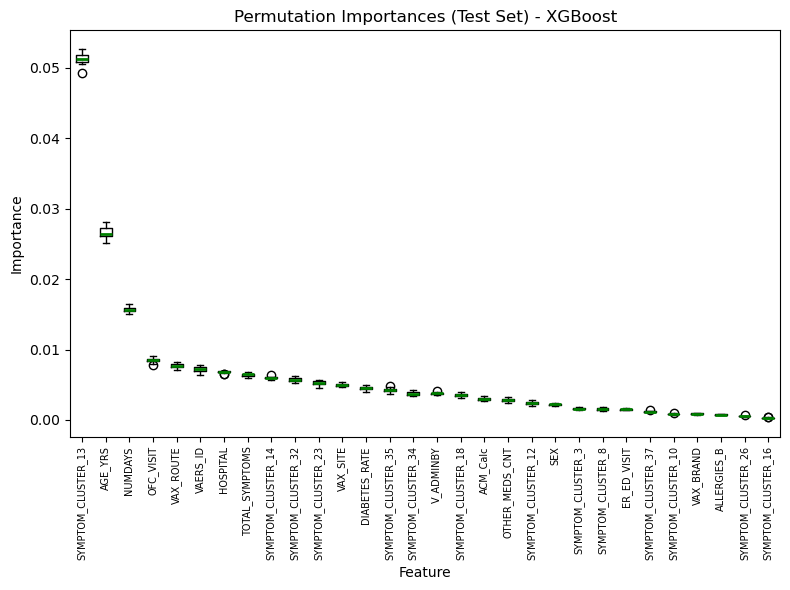

In [20]:
sens = permutation_importance(best_boost, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc')

# getting importances
importances_mean = sens.importances_mean
importances_std  = sens.importances_std
importances      = sens.importances

# sort features by mean importance (descending) for the plot
sorted_idx      = np.argsort(importances_mean)[::-1]
sorted_features = X_test.columns[sorted_idx]

# create a vertical boxplot of permutation importances
plt.figure(figsize=(8, 6))
plt.boxplot(importances[sorted_idx].T, vert=True, tick_labels=sorted_features,medianprops=dict(color="green", linewidth=2))
plt.title('Permutation Importances (Test Set) - XGBoost')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


### Performance Evaluation

We now evaluate model performance on the test set. We compute the ROC curves for all three models, plot them together with the random guess (50% chance) line, and also provide confusion matrices and classification figures

## 4. Feature Importance Analysis

In this section we compute and visualize feature importance for the three models. For tree-based models (Random Forest and Boosting), we use the built in feature_importances_ attributes. For Logistic, we use the absolute values of its coefficients as a measure of importance. We then plot these values as bar charts for comparison.

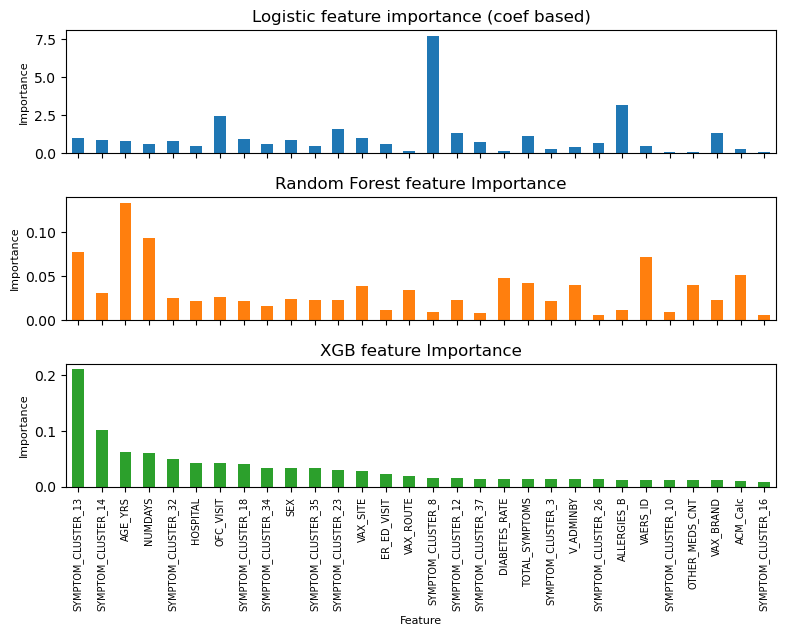

In [21]:
features = X_train.columns

# Logistic 
lr_importance = np.abs(best_lr.coef_[0])

# Random Forest and XGB
rf_importance = best_rf.feature_importances_
boost_importance = best_boost.feature_importances_

# single dataset for visualization
importance_df = pd.DataFrame({'Feature': features,'Logistic Importance': lr_importance,
                              'Random Forest Importance': rf_importance,'XGB Importance': boost_importance}).set_index('Feature')
# Use XGB as a base
importance_df = importance_df.sort_values(by='XGB Importance', ascending=False)

# plot configuration
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

importance_df['Logistic Importance'].plot(kind='bar', ax=axs[0], color='C0')
axs[0].set_title('Logistic feature importance (coef based)')
axs[0].set_ylabel('Importance')

importance_df['Random Forest Importance'].plot(kind='bar', ax=axs[1], color='C1')
axs[1].set_title('Random Forest feature Importance')
axs[1].set_ylabel('Importance')

importance_df['XGB Importance'].plot(kind='bar', ax=axs[2], color='C2')
axs[2].set_title('XGB feature Importance')
axs[2].set_ylabel('Importance')

plt.tight_layout()
axs[0].set_ylabel('Importance', fontsize=8)   
axs[1].set_ylabel('Importance', fontsize=8)   
axs[2].set_ylabel('Importance', fontsize=8)   
plt.xlabel('Feature', fontsize=8)   
plt.xticks(fontsize=7)
plt.show()

## 4. Feature Ablation Analysis  

In this section we perform feature ablation analysis. For each feature, we remove it from the training and test sets, retrain a Logistic Regression model using the best hyperparameter (C) from the full model, and compute the drop in ROC AUC compared to the full model. This drop in performance indicates the contribution of that feature to the model's predictive power.

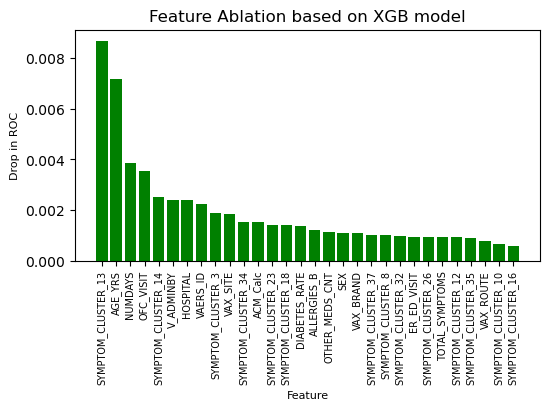

In [22]:
# baseline xgb performance
baseline = roc_auc_score(y_test, best_boost.predict_proba(X_test)[:, 1])

# perform feature ablation analysis using xgb model
feature_drops = {}
for feat in X_train.columns:
    # drop current feature from train and test sets
    X_train_abl = X_train.drop(columns=[feat])
    X_test_abl = X_test.drop(columns=[feat])
    #print(feat,len(X_train_abl.columns))
    # create a new xgb model with the best boost parameters
    params = best_boost.get_params()
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_abl, y_train, sample_weight=sample_weight)
    
    # compute performance on the ablated dataset
    perf = roc_auc_score(y_test, model.predict_proba(X_test_abl)[:, 1])
    drop = baseline - perf
    #print (baseline, perf, drop)
    feature_drops[feat] = drop

# sort features by drop in performance
sorted_feat = sorted(feature_drops, key=feature_drops.get, reverse=True)
sorted_drops = [feature_drops[f] for f in sorted_feat]

# plot feature importance ranking
plt.figure(figsize=(6, 3))
plt.bar(sorted_feat, sorted_drops,color='green')
plt.xlabel('Feature', fontsize=8)
plt.ylabel('Drop in ROC', fontsize=8)
plt.title('Feature Ablation based on XGB model')
plt.xticks(rotation=90, fontsize=7)
plt.show()


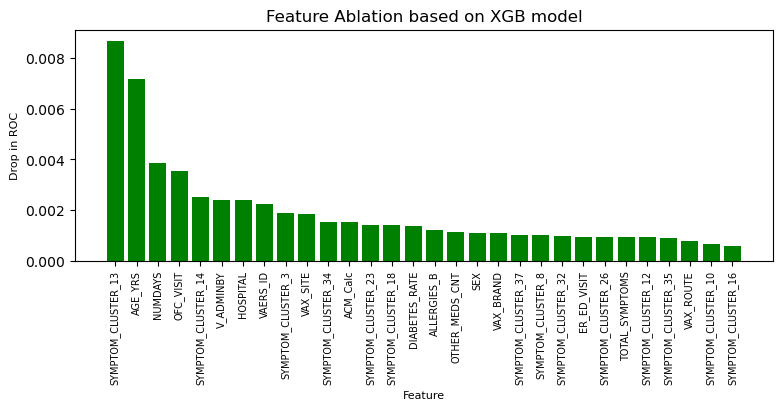

In [23]:
# plot feature importance ranking
plt.figure(figsize=(9, 3))
plt.bar(sorted_feat, sorted_drops,color='green')
plt.xlabel('Feature', fontsize=8)
plt.ylabel('Drop in ROC', fontsize=8)
plt.title('Feature Ablation based on XGB model')
plt.xticks(rotation=90, fontsize=7)
plt.show()

## 8. SHAP Variable Importance Analysis

In this section, we use SHAP (SHapley Additive exPlanations) to interpret the predictions of our best XGBoost model. We compute SHAP values on the test set using a TreeExplainer, then display a bar plot that shows the average absolute SHAP values for each feature. This gives us a clear view of the variable importance based on the model’s output.

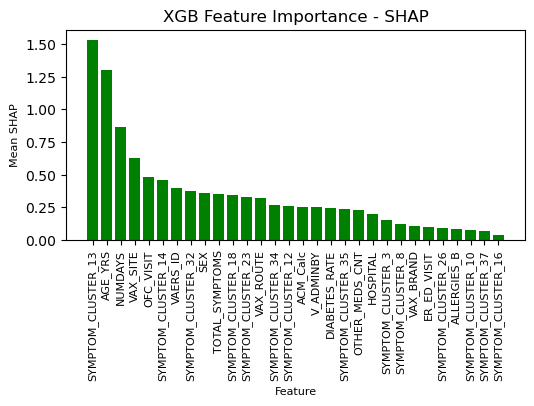

In [24]:
explainer = shap.TreeExplainer(best_boost)
shap_values = explainer.shap_values(X_test)

#shap.summary_plot(shap_values, X_test, plot_type="bar")    # need to reshape chart to have a better view

mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_names = X_test.columns

# descending for plot
feat_imp = (pd.DataFrame({'feature': feature_names, 'importance': mean_abs_shap}).sort_values('importance', ascending=False))

plt.figure(figsize=(6,3))
plt.bar(feat_imp['feature'], feat_imp['importance'], color='green')
plt.xlabel('Feature',fontsize=8)
plt.ylabel('Mean SHAP',fontsize=8)
plt.title('XGB Feature Importance - SHAP')
plt.tight_layout()
plt.xticks(rotation=90,fontsize=8)
plt.show()

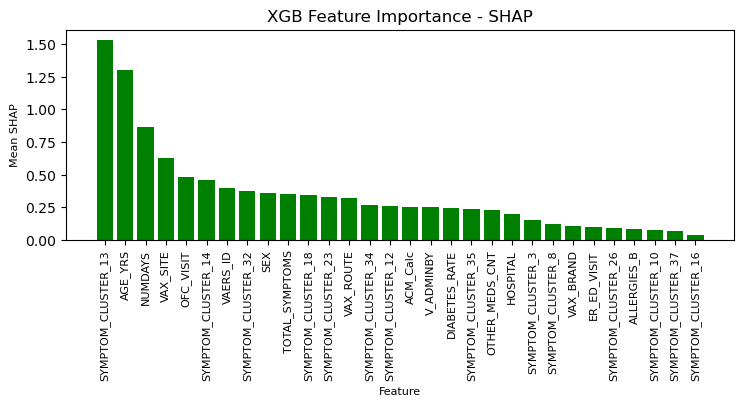

In [25]:
plt.figure(figsize=(8,3))
plt.bar(feat_imp['feature'], feat_imp['importance'], color='green')
plt.xlabel('Feature',fontsize=8)
plt.ylabel('Mean SHAP',fontsize=8)
plt.title('XGB Feature Importance - SHAP')
plt.tight_layout()
plt.xticks(rotation=90,fontsize=8)
plt.show()

### SENSITIVITY


### LEARNING CURVES
    

### FAILURE


In [31]:
temp_df = pd.read_csv('/users/deriv/MADS/0.696_programming/assets/symptom_cluster.csv', low_memory=False) 
cluster_sets = temp_df.groupby('CLUSTER')['SYMPTOM'].apply(set).to_dict()
len(temp_df['CLUSTER'].unique())

45

In [27]:
cluster_sets[13]

{'Abdominal adhesions',
 'Abdominal discomfort',
 'Abdominal distension',
 'Abdominal pain lower',
 'Abdominal pain upper',
 'Abdominal rigidity',
 'Abnormal faeces',
 'Abnormal menstrual clots',
 'Accessory muscle',
 'Accessory spleen',
 'Acquired oesophageal web',
 'Acrochordon',
 'Adenoidal disorder',
 'Adenoiditis',
 'Adrenal disorder',
 'Airway burns',
 'Airway secretion clearance therapy',
 'Amenorrhoea',
 'Amniotic cavity infection',
 'Anal inflammation',
 'Anal skin tags',
 'Anogenital warts',
 'Anorectal discomfort',
 'Anorectal disorder',
 'Anorectal swelling',
 'Appendicolith',
 'Arachnoid web',
 'Asplenia',
 'Asymptomatic COVID-19',
 'Asymptomatic bacteriuria',
 'Atrophy',
 'Atrophy of globe',
 'Azoospermia',
 'Bladder pain',
 'Blood brain barrier defect',
 'Bowel movement irregularity',
 'Breast discharge',
 'Breast discomfort',
 'Breast induration',
 'Breast inflammation',
 'Breast pain',
 'Breast swelling',
 'Bronchial disorder',
 'Bronchial hyperreactivity',
 'Bronchial